<a href="https://colab.research.google.com/github/zain4cs/Unsupervised_Learning/blob/main/K_means.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [59]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [60]:
X, y_true   = make_blobs(n_samples=300, centers=4, cluster_std=0.06, random_state=42)

In [61]:
df = pd.DataFrame(X, columns=['Feature_1', 'Feature_2'])
df.head()

,Feature_1,Feature_2
0,-8.865889,7.272532
1,-8.889953,7.300450
2,-2.459845,8.941036
3,-6.892688,-6.814183
4,-8.960615,7.263038


_____________________

In [62]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

In [63]:
inertia = []
k_range = range(1, 11)

In [64]:
for k in k_range:
  kmeans = KMeans(n_clusters=k, random_state=42)
  kmeans.fit(X_scaled)
  inertia.append(kmeans.inertia_)

In [65]:
inertia

[599.9999999999995,
 307.58275788749285,
 58.773885748111404,
 0.06472480397428781,
 0.058002156851867756,
 0.05301672913810808,
 0.04634007788866698,
 0.04378114733261086,
 0.0390625593634688,
 0.035228917605150054]

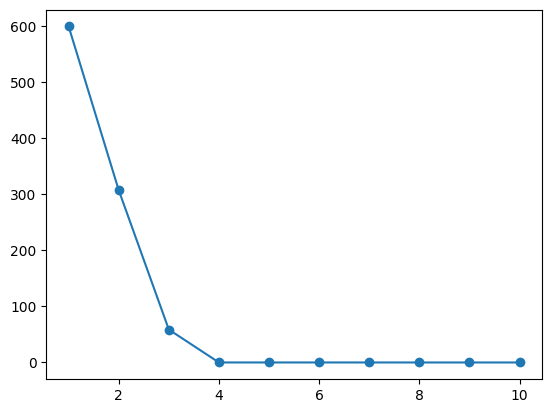

In [66]:
plt.plot(k_range, inertia, marker='o')

_____________

**Final Cluster**

In [67]:
kmeans_final = KMeans(n_clusters=4, random_state=42)

In [68]:
cluster_labels = kmeans_final.fit_predict(X_scaled)

In [69]:
df['clusters'] = cluster_labels

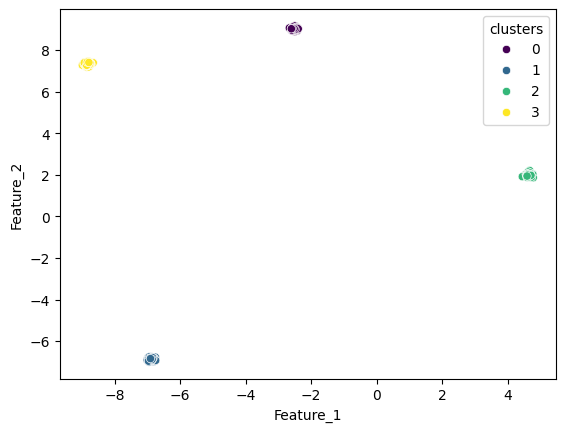

In [70]:
sns.scatterplot(
    x=df['Feature_1'],
    y=df['Feature_2'],
    hue=df['clusters'],
    palette='viridis'
)

plt.show()